<a href="https://colab.research.google.com/github/selha-jaleel/Addon-course/blob/main/Day_3_Dog_And_Cat_Program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

zip_path = '/content/zzddccc.zip'
extract_path = '/content/zzddccc_extracted'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List the extracted files
extracted_files = []
for root, dirs, files in os.walk(extract_path):
    for file in files:
        extracted_files.append(os.path.join(root, file))

print(f"Extracted {len(extracted_files)} files:")
for f in extracted_files:
    print(f)

Extracted 23 files:
/content/zzddccc_extracted/zzddcc/dogs/images (1).jpg
/content/zzddccc_extracted/zzddcc/dogs/images (5).jpg
/content/zzddccc_extracted/zzddcc/dogs/images (7).jpg
/content/zzddccc_extracted/zzddcc/dogs/images (3).jpg
/content/zzddccc_extracted/zzddcc/dogs/images (4).jpg
/content/zzddccc_extracted/zzddcc/dogs/images (10).jpg
/content/zzddccc_extracted/zzddcc/dogs/images (9).jpg
/content/zzddccc_extracted/zzddcc/dogs/bf08f390-87e9-11f0-b36e-47414de99d82.jpg
/content/zzddccc_extracted/zzddcc/dogs/images (6).jpg
/content/zzddccc_extracted/zzddcc/dogs/images.jpg
/content/zzddccc_extracted/zzddcc/dogs/images (2).jpg
/content/zzddccc_extracted/zzddcc/dogs/images (8).jpg
/content/zzddccc_extracted/zzddcc/cats/images (13).jpg
/content/zzddccc_extracted/zzddcc/cats/images (17).jpg
/content/zzddccc_extracted/zzddcc/cats/images (16).jpg
/content/zzddccc_extracted/zzddcc/cats/images (11).jpg
/content/zzddccc_extracted/zzddcc/cats/images (21).jpg
/content/zzddccc_extracted/zzddcc/

### Image Dataset Analysis
The ZIP file contains images categorized into folders. I will now visualize samples from the 'cats' and 'dogs' directories.

Found 12 dog images and 11 cat images.


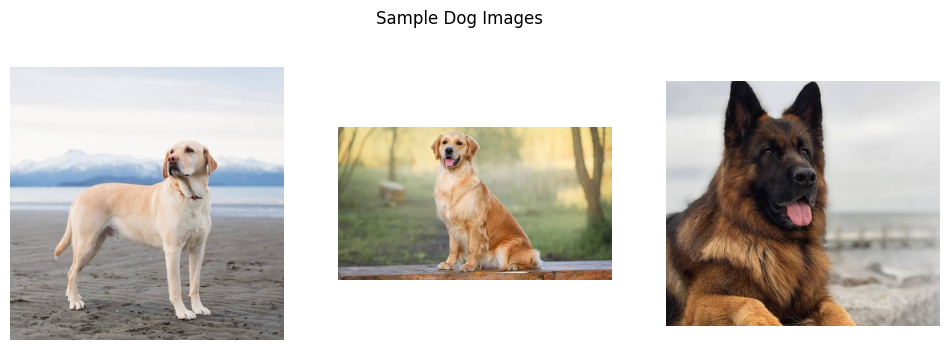

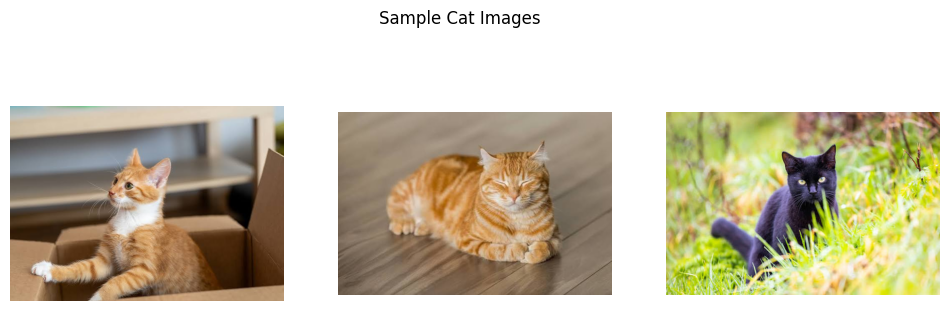

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def plot_samples(files, title, num=3):
    plt.figure(figsize=(12, 4))
    for i, img_path in enumerate(files[:num]):
        plt.subplot(1, num, i + 1)
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

dog_files = [f for f in extracted_files if '/dogs/' in f]
cat_files = [f for f in extracted_files if '/cats/' in f]

print(f"Found {len(dog_files)} dog images and {len(cat_files)} cat images.")

if dog_files:
    plot_samples(dog_files, 'Sample Dog Images')
if cat_files:
    plot_samples(cat_files, 'Sample Cat Images')

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Define paths
base_dir = '/content/zzddccc_extracted/zzddcc'

# Improved Preprocessing with Data Augmentation to help with the small dataset
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=4,
    class_mode='binary',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=4,
    class_mode='binary',
    subset='validation'
)

Found 19 images belonging to 2 classes.
Found 4 images belonging to 2 classes.


In [ ]:
# Use Transfer Learning with MobileNetV2 for better results on a small dataset
base_model = tf.keras.applications.MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/tmp/ipykernel_1152/3551143928.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Retrain the new Transfer Learning model
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    verbose=1
)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 542ms/step - accuracy: 0.3684 - loss: 0.9786 - val_accuracy: 0.2500 - val_loss: 0.9200
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - accuracy: 0.6842 - loss: 0.5930 - val_accuracy: 0.2500 - val_loss: 1.1708
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 326ms/step - accuracy: 0.7368 - loss: 0.3789 - val_accuracy: 0.7500 - val_loss: 0.5265
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.8421 - loss: 0.3509 - val_accuracy: 0.5000 - val_loss: 0.8305
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - accuracy: 1.0000 - loss: 0.2095 - val_accuracy: 0.5000 - val_loss: 0.6821
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.9474 - loss: 0.2582 - val_accuracy: 1.0000 - val_loss: 0.3118
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.9474 - loss: 0.1523 - val_accuracy: 0.7500 - val_loss: 0.4532
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 1.0000 - loss: 0.1367 - val_accuracy: 0.7500 - val_loss:

Final check with Transfer Learning model:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


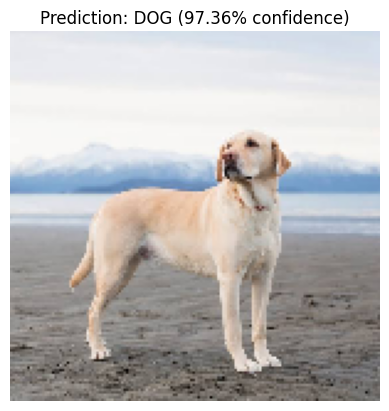

In [ ]:
# Final verification with Transfer Learning model
if dog_files:
    print("Final check with Transfer Learning model:")
    predict_and_show(dog_files[0])

In [ ]:
predict_image('/content/images (18).jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
/content/images (18).jpg: It is a CAT


In [ ]:
predict_image('/content/images (15).jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
/content/images (15).jpg: It is a CAT


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


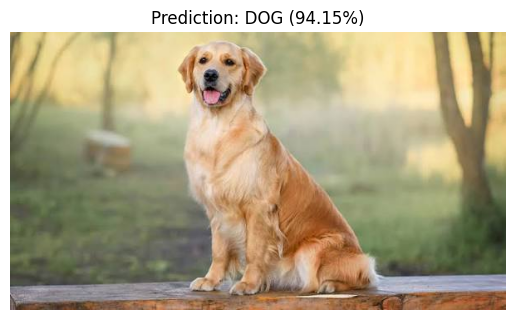

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def predict_and_show(img_path):
    # Re-using the logic from your predict_image function but adding plot
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(150, 150))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) / 255.0

    prediction = model.predict(img_array)
    label = 'DOG' if prediction[0][0] > 0.5 else 'CAT'
    confidence = prediction[0][0] if label == 'DOG' else 1 - prediction[0][0]

    plt.imshow(mpimg.imread(img_path))
    plt.title(f"Prediction: {label} ({confidence:.2%})")
    plt.axis('off')
    plt.show()

predict_and_show('/content/images (5).jpg')